# The gene pair inspection

loading the data

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
# Correct and verified path to the file
# Getting the 48 Xenium slides from the David dataset
output_h5ad_path = "/scratch/project_465001027/Spatialformer/data/gene_pair.h5ad"
# Load the AnnData object from the .h5ad file
adata = sc.read_h5ad(output_h5ad_path)


In [2]:
adata.X

<892167x72266 sparse matrix of type '<class 'numpy.int64'>'
	with 44607258 stored elements in Compressed Sparse Row format>

In [3]:
adata.obs

,Niche_Annotations,Annotations
VUILD107MF_aaaabokj-1,T2,B cells
VUILD107MF_aaaabpfm-1,T2,T-cells
VUILD107MF_aaaabpgd-1,T2,B cells
VUILD107MF_aaaabojm-1,T5,Macrophages
VUILD107MF_aaaabkng-1,T9,Fibroblasts
...,...,...
VUHD113_aaaabfjf-1,T4,SMCs
VUHD113_aaaabfji-1,T9,Fibroblasts
VUHD113_aaaabfjh-1,T4,T-cells
VUHD113_aaaabcnd-1,T4,Alveolar FBs


Assign the batch information to the cell meta data

In [14]:
adata.obs["Batch"] = adata.obs.index.map(lambda x: x.split("_")[0])

In [15]:
adata.obs["Batch"]

VUILD107MF_aaaabokj-1    VUILD107MF
VUILD107MF_aaaabpfm-1    VUILD107MF
VUILD107MF_aaaabpgd-1    VUILD107MF
VUILD107MF_aaaabojm-1    VUILD107MF
VUILD107MF_aaaabkng-1    VUILD107MF
                            ...    
VUHD113_aaaabfjf-1          VUHD113
VUHD113_aaaabfji-1          VUHD113
VUHD113_aaaabfjh-1          VUHD113
VUHD113_aaaabcnd-1          VUHD113
VUHD113_aaaabfik-1          VUHD113
Name: Batch, Length: 892167, dtype: object

Calculating the quality score

In [16]:
sc.pp.calculate_qc_metrics(
    adata, inplace=True, log1p=True
)

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:793: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


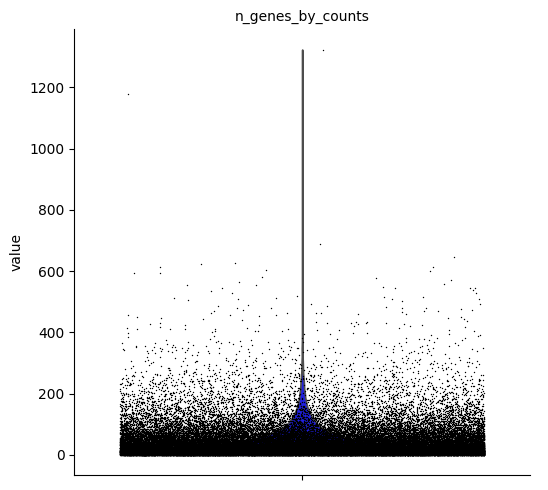

In [38]:
ax = sc.pl.violin(
    subann_adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
    palette=["blue"],
    show=False
)

# Access the current figure
fig = plt.gcf()
ax = plt.gca()  # Get the current axes
# # Add more padding between the annotations and the figure
plt.tight_layout()
# # Show and save the modified plot
plt.show()
# Save the figure using matplotlib's savefig
fig.savefig("/scratch/project_465001820/Spatialformer/Figure/n_genes_by_counts_violin.png", dpi=300, bbox_inches='tight', format='png')

# Close the figure to free up memory, especially in scripts
plt.close(fig)

Normalization

In [4]:
# Saving count data
# adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
# sc.pp.normalize_total(adata)
# Logarithmize the data
# sc.pp.log1p(adata)

Get highvariale genes

In [18]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

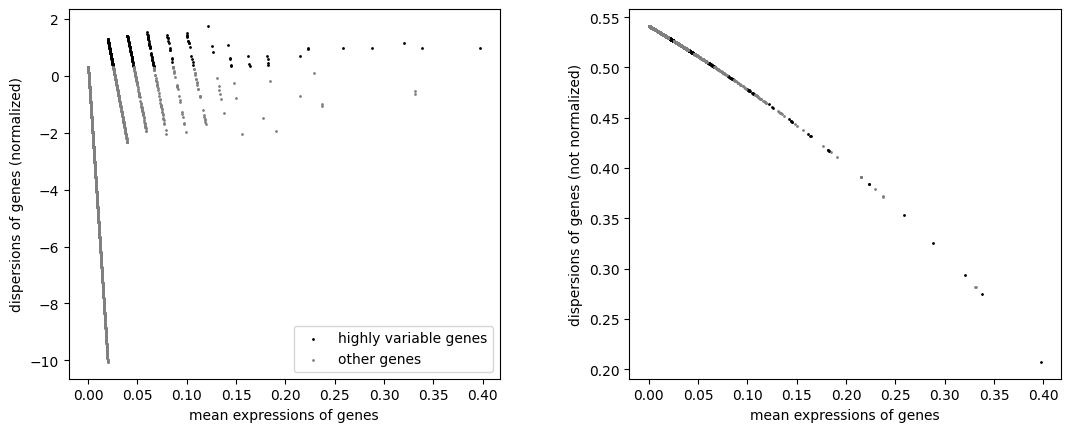

In [19]:
sc.pl.highly_variable_genes(adata)

Dimension reduction of the features

In [20]:
if not np.issubdtype(adata.X.dtype, np.floating):
    adata.X = adata.X.astype(np.float64)  # Convert to float
sc.tl.pca(adata)

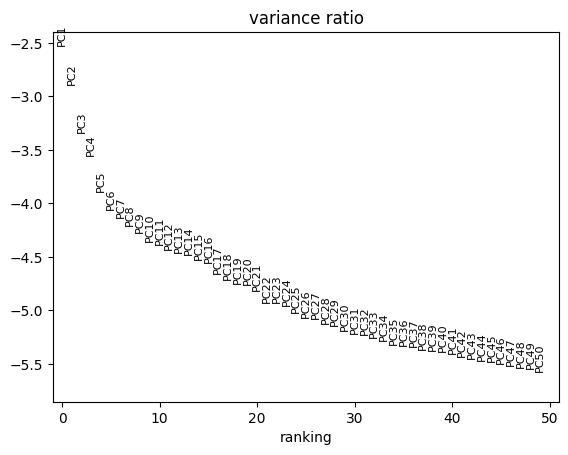

In [21]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

Subsetting the data according to the annotations

In [22]:
# Define the fraction of samples to keep from each category
frac_to_keep = 0.1
print("subsetting")
# Group by 'Annotations' and sample the desired fraction from each category
sampled_indices = (adata.obs.groupby("Annotations")
                   .apply(lambda x: x.sample(frac=frac_to_keep, random_state=42))
                   .index.get_level_values(1))

# Create a subset AnnData object using the sampled indices
subann_adata = adata[sampled_indices].copy()

subsetting


In [33]:
subset_batch_indix = np.where(adata.obs["Batch"].isin(["THD0008"]))
subann_adata = adata[subset_batch_indix].copy()

In [34]:
subann_adata.obs

,Niche_Annotations,Annotations,Batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
THD0008_aaaaccbc-1,T5,Macrophages,THD0008,31,3.465736,31,3.465736,100.000000,100.000000,100.0,100.0
THD0008_aaaacael-1,T5,Macrophages,THD0008,9,2.302585,9,2.302585,100.000000,100.000000,100.0,100.0
THD0008_aaababop-1,T12,Alveolar FBs,THD0008,29,3.401197,29,3.401197,100.000000,100.000000,100.0,100.0
THD0008_aaabamch-1,T2,T-cells,THD0008,102,4.634729,102,4.634729,49.019608,98.039216,100.0,100.0
THD0008_aaabacej-1,T5,Interstitial Macrophages,THD0008,21,3.091042,21,3.091042,100.000000,100.000000,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...
THD0008_aaabacfn-1,T9,gCap,THD0008,87,4.477337,87,4.477337,57.471264,100.000000,100.0,100.0
THD0008_aaabahec-1,T9,Fibroblasts,THD0008,15,2.772589,15,2.772589,100.000000,100.000000,100.0,100.0
THD0008_aaabahha-1,T2,T-cells,THD0008,18,2.944439,18,2.944439,100.000000,100.000000,100.0,100.0
THD0008_aaabaagh-1,T9,Fibroblasts,THD0008,29,3.401197,29,3.401197,100.000000,100.000000,100.0,100.0


In [35]:
# Subset the data by these highly variable genes
adata_hvg = adata[:, adata.var.highly_variable].copy()
subann_adata_hvg = subann_adata[:, subann_adata.var.highly_variable].copy()

plotting UMAP

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


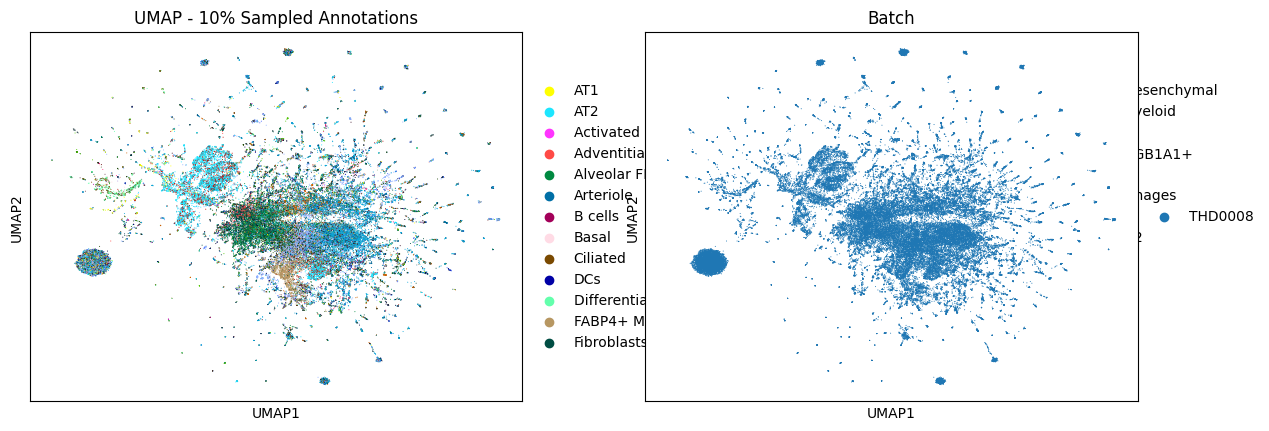

In [36]:
# Assume 'adata' is your original AnnData object
sc.pp.normalize_total(subann_adata_hvg, target_sum=1e4)
sc.pp.log1p(subann_adata_hvg)
# Perform PCA to reduce dimensionality
sc.pp.pca(subann_adata_hvg, n_comps=40)  # You can adjust the number of components
# Compute nearest neighbors using the PCA representation
sc.pp.neighbors(subann_adata_hvg, use_rep='X_pca')
# Run UMAP on the subset data
sc.tl.umap(subann_adata_hvg, spread =2, min_dist = 0.5, random_state=42)
# Plot the UMAP
sc.pl.umap(subann_adata_hvg, color=['Annotations', "Batch"], title="UMAP - 10% Sampled Annotations")

In [12]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
# sc.tl.leiden(subann_adata_hvg, resolution=1.0, random_state=42, n_iterations=2)
# sc.pl.umap(subann_adata_hvg, color=["leiden"])

Calculating the differential expression genes

In [37]:
import pandas as pd
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata_hvg, groupby="Annotations", method="wilcoxon")
# Save the DataFrame to a CSV file
# List to store DataFrames for each group
df_list = []

# Retrieve the list of groups
groups = adata_hvg.uns['rank_genes_groups']['names'].dtype.names

# Iterate through each group and compile the results
for group in groups:
    # Extract the DataFrame for the current group
    ranked_genes_df = sc.get.rank_genes_groups_df(adata_hvg, group=group)
    
    # Add a new column to indicate the group
    ranked_genes_df['group'] = group
    
    # Append the DataFrame to the list
    df_list.append(ranked_genes_df)

# Concatenate all group DataFrames into a single DataFrame
all_groups_df = pd.concat(df_list, ignore_index=True)

# Save the combined DataFrame to a CSV file
output_csv_path = "/scratch/project_465001027/Spatialformer/data/ranked_genes_all_groups.csv"
all_groups_df.to_csv(output_csv_path, index=False)

print(f"Complete differential expression results saved to {output_csv_path}")


ValueError: Could not calculate statistics for groups KRT5-/KRT17+ since they only contain one sample.

i want to make a heatmap of all these filtered gene pairs

In [14]:
#selecting the top 10 gene pairs for cell types according to logfoldchanges
# Assuming 'logfoldchanges' column is available and you want to sort by it
# ranked_genes_df_sorted = ranked_genes_df.sort_values(by='logfoldchanges', ascending=False)
# Retrieve the list of groups (clusters) analyzed
groups = adata_hvg.uns['rank_genes_groups']['names'].dtype.names
# Create a DataFrame to store top markers for all groups
top_markers_all_clusters = pd.DataFrame()
# Iterate over each group/cluster
for group in groups:
    # Extract ranked genes for the current group
    ranked_genes_df = sc.get.rank_genes_groups_df(adata_hvg, group=group)
    positive_logfc_df = ranked_genes_df[(ranked_genes_df['logfoldchanges'] > 0) & (ranked_genes_df['pvals_adj'] < 0.05)]
    
    # Sort by adjusted p-value ('pvals_adj') and log fold changes ('logfoldchanges')
    ranked_genes_df_sorted = positive_logfc_df.sort_values(by=['pvals_adj', 'logfoldchanges'], ascending=[True, False])
    
    # Select top 10 genes
    top_10_markers_df = ranked_genes_df_sorted.head(5)
    
    # Add a column for the cluster/group for clarity
    top_10_markers_df['cluster'] = group
    
    # Append to the main DataFrame
    top_markers_all_clusters = pd.concat([top_markers_all_clusters, top_10_markers_df], ignore_index=True)



/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_markers_df['cluster'] = group
/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_markers_df['cluster'] = group
/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_markers_df['cluster'] = group
/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_markers_df['cluster'] = group
/tmp/ipykernel_119344/4172682264.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [25]:
top_markers_all_clusters

,names,scores,logfoldchanges,pvals,pvals_adj,cluster
0,"('EPCAM', 'ICAM1')",27.602551,3.898141,1.036957e-167,2.527324e-164,AT1
1,"('CEACAM6', 'ICAM1')",24.896687,3.907086,8.081152e-137,1.313053e-133,AT1
2,"('FN1', 'ICAM1')",23.938461,3.589346,1.218622e-126,1.485043e-123,AT1
3,"('ITGB1', 'ICAM1')",22.493736,3.460304,4.780064e-112,5.177872e-109,AT1
4,"('NAPSA', 'ICAM1')",18.092785,3.264076,3.632617e-73,2.529599e-70,AT1
...,...,...,...,...,...,...
187,"('HERPUD1', 'VIM')",15.428482,3.008823,1.053184e-53,1.026749e-49,pDCs
188,"('VIM', 'JCHAIN')",13.751184,3.215967,5.010251e-43,2.442247e-39,pDCs
189,"('JCHAIN', 'VIM')",12.636822,2.440066,1.322946e-36,4.299133e-33,pDCs
190,"('HERPUD1', 'HLA-DRA')",10.550750,3.412130,5.039311e-26,1.228206e-22,pDCs


In [21]:
#getting the dict of the group: markers
# Create a dictionary where each group is a key, and values are lists of names
marker_pairs_dict = top_markers_all_clusters.groupby("cluster")["names"].apply(list).to_dict()

In [17]:
marker_pairs_dict

{'AT1': ["('EPCAM', 'ICAM1')",
  "('CEACAM6', 'ICAM1')",
  "('FN1', 'ICAM1')",
  "('ITGB1', 'ICAM1')",
  "('NAPSA', 'ICAM1')",
  "('ATF4', 'ICAM1')",
  "('SFTPD', 'ICAM1')",
  "('EPCAM', 'VIM')",
  "('KRT8', 'VIM')",
  "('ITGB1', 'RNASE1')",
  "('KRT18', 'KRT8')",
  "('VIM', 'RNASE1')",
  "('SFTPD', 'VIM')",
  "('CEACAM6', 'SFTPC')",
  "('MGST1', 'ICAM1')",
  "('ATF4', 'RNASE1')",
  "('VIM', 'EPAS1')",
  "('ICAM1', 'RNASE1')",
  "('CEACAM6', 'NAPSA')",
  "('ITGB1', 'SFTPC')",
  "('NKX2-1', 'SFTPD')",
  "('NAPSA', 'FN1')",
  "('KRT18', 'SFTPD')",
  "('ITGB1', 'CCN2')",
  "('EPCAM', 'SFTPD')",
  "('SFTPC', 'VIM')",
  "('RNASE1', 'SFTPD')",
  "('KRT8', 'SFTPD')",
  "('MGST1', 'RNASE1')",
  "('RHOA', 'NAPSA')"],
 'AT2': ["('LAMP3', 'SFTPD')",
  "('DUOX1', 'SFTPC')",
  "('LAMP3', 'NAPSA')",
  "('MGST1', 'SFTPD')",
  "('LAMP3', 'CD44')",
  "('EPAS1', 'SFTPD')",
  "('DMBT1', 'SFTPC')",
  "('XBP1', 'PGC')",
  "('RNASE1', 'SFTPD')",
  "('CD44', 'NAPSA')",
  "('EPAS1', 'PGC')",
  "('MGST1', 'DMB

categories: AT1, AT2, Activated FBs, etc.
var_group_labels: AT1, AT2, Activated FBs, etc.


/tmp/ipykernel_121462/4011080912.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


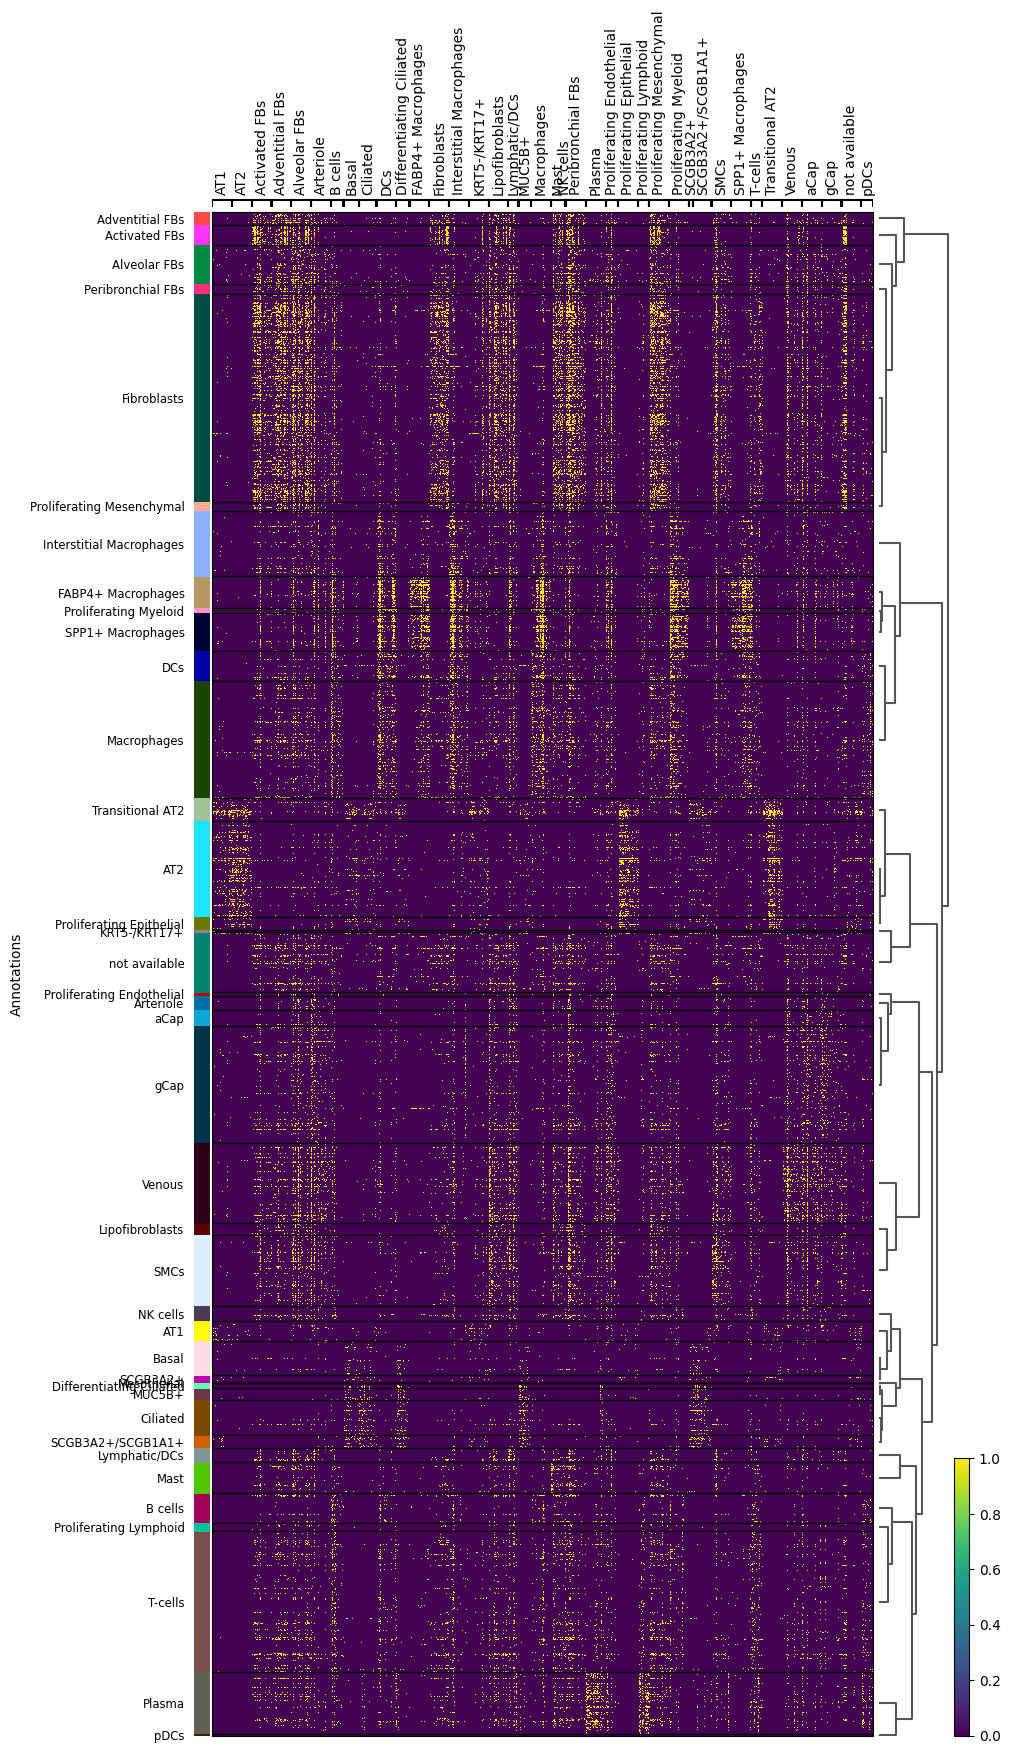

In [18]:
#define the marker gene 
#Here i select the top 5 gene pair markers
# Reorder columns in adata by specified 'ordered_labels'
# adata_hvg = adata_hvg[:, np.array([marker for marker in marker_pairs_dict])]
adata_sorted = adata_hvg[adata_hvg.obs.sort_values("Annotations").index].copy()



ax = sc.pl.heatmap(
    adata_sorted,
    marker_pairs_dict, 
    groupby="Annotations", 
    cmap="viridis", 
    dendrogram=True,
    figsize=(10, 20), 
    swap_axes=False,
    show=False
)
# Customize the heatmap aesthetics with matplotlib after plotting
fig = plt.gcf()  # Get the current figure from the plot
ax = plt.gca()  # Get the current axes

# # Add more padding between the annotations and the figure
plt.tight_layout()

# # Show and save the modified plot
plt.show()

# Optional: Save the arranged heatmap
fig.savefig("/scratch/project_465001027/Spatialformer/Figure/arranged_heatmap.png", dpi=300, bbox_inches='tight')
# Close the figure to free up memory, especially in scripts
plt.close(fig)

In [19]:
adata_hvg.obs

,Niche_Annotations,Annotations,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
cell_0,T2,B cells,9,2.302585,9,2.302585,100.0,100.0,100.0,100.0
cell_1,T2,T-cells,7,2.079442,7,2.079442,100.0,100.0,100.0,100.0
cell_2,T2,B cells,2,1.098612,2,1.098612,100.0,100.0,100.0,100.0
cell_3,T5,Macrophages,35,3.583519,35,3.583519,100.0,100.0,100.0,100.0
cell_4,T9,Fibroblasts,36,3.610918,36,3.610918,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...,...,...,...
cell_892162,T4,SMCs,4,1.609438,4,1.609438,100.0,100.0,100.0,100.0
cell_892163,T9,Fibroblasts,1,0.693147,1,0.693147,100.0,100.0,100.0,100.0
cell_892164,T4,T-cells,11,2.484907,11,2.484907,100.0,100.0,100.0,100.0
cell_892165,T4,Alveolar FBs,24,3.218876,24,3.218876,100.0,100.0,100.0,100.0


In [22]:
import scanpy as sc
# markers = ["('JCHAIN', 'HLA-DRA')", "('STAT1', 'HLA-DRA')", "('VIM', 'HLA-DRA')"]
cluster_list = ["Basal", "Transitional AT2", "AT2", "AT1", "Ciliated", "Differentiating Ciliated", "MUCSB+", "SCGB3A2+", "SCGB3A2+/SCGB1A1+"
                "Proliferating", "KRT5-/KRT17+", 
               ]

adata_dot = adata[adata.obs["Annotations"].isin(cluster_list),:]

# marker_cluster = ["AT2", "AT1", "Ciliated", "Differentiating Ciliated", "Basal"]
marker_cluster = cluster_list
markers = top_markers_all_clusters[top_markers_all_clusters["cluster"].isin(marker_cluster)]["names"].values

import matplotlib.pyplot as plt

# Plot without immediately saving or displaying
sc.pl.dotplot(
    adata_dot, 
    markers, 
    groupby='Annotations', 
    dendrogram=True, 
    show=False
)

# Get the current figure and save it
plt.savefig("/scratch/project_465001027/Spatialformer/Figure/pair_dotplot.png", dpi=300, bbox_inches='tight')

# Clear the plot
plt.close()



/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/scratch/project_465001027/deeploc_torch/lib/python3.8/contextlib.py:120: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)
/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


plot the violin plot to show the expression level of some gene pairs

In [31]:
# marker_cluster = ["AT2", "AT1", "Ciliated", "Differentiating Ciliated", "Basal"]
marker_cluster = ["Differentiating Ciliated"]
markers = top_markers_all_clusters[top_markers_all_clusters["cluster"].isin(marker_cluster)]["names"].values

for pair in markers:
    # Generate the violin plot without displaying it immediately
    sc.pl.violin(
        adata_dot, 
        pair, 
        groupby="Annotations", 
        show=False  # Prevents the plot from showing
    )
    # Rotate x-labels by 60 degrees
    plt.xticks(rotation=60)
    # Save the current figure
    plt.savefig(f"/scratch/project_465001027/Spatialformer/Figure/violin_plot_differential_ciliated_{pair}.png", dpi=300, bbox_inches='tight')

    # Clear the plot to free up memory
    plt.close()

/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/project_465001027/deeploc_torch/lib/python3.8/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The